# Patient Health Records: Missing Value and Outlier Handling



In [ ]:
df = pd.read_csv('data/patient_health_records.csv')
print('Dataset shape:', df.shape)
display(df.head(10))

Dataset shape: (220, 9)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P001,51.0,Male,East,28.46,158.25,197.67,158.48,1
1,P002,33.0,Female,West,23.27,124.01,205.50,105.37,0
2,P003,57.0,Female,East,30.64,162.38,215.86,129.37,1
3,P004,59.0,Male,East,17.26,148.68,183.96,141.81,0
4,P005,22.0,Male,East,21.89,125.83,183.20,100.66,0
5,P006,30.0,Male,North,NaN,134.79,NaN,97.06,0
6,P007,49.0,Female,North,22.82,147.20,180.54,NaN,0
7,P008,43.0,Female,East,26.66,147.68,206.62,320.49,1
8,P009,47.0,Female,North,25.20,148.19,215.96,NaN,1
9,P010,36.0,Female,North,24.48,137.40,199.08,115.21,1


In [190]:
df.info()
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      220 non-null    object 
 1   age             203 non-null    float64
 2   gender          207 non-null    object 
 3   region          209 non-null    object 
 4   bmi             198 non-null    float64
 5   blood_pressure  220 non-null    float64
 6   cholesterol     194 non-null    float64
 7   glucose         198 non-null    float64
 8   disease_risk    220 non-null    int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 15.6+ KB


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,220,203.000000,207,209,198.000000,220.000000,194.000000,198.000000,220.000000
unique,220,NaN,2,4,NaN,NaN,NaN,NaN,NaN
top,P001,NaN,Female,East,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,111,57,NaN,NaN,NaN,NaN,NaN
mean,NaN,46.315271,NaN,NaN,26.488434,146.282500,213.641392,138.005556,0.468182
std,NaN,11.616782,NaN,NaN,6.403802,19.453095,40.726702,42.989402,0.500125
min,NaN,20.000000,NaN,NaN,17.000000,99.980000,157.200000,87.730000,0.000000
25%,NaN,38.000000,NaN,NaN,22.660000,135.890000,194.805000,118.060000,0.000000
50%,NaN,46.000000,NaN,NaN,25.730000,144.345000,206.485000,130.360000,0.000000
75%,NaN,53.500000,NaN,NaN,28.327500,153.250000,218.762500,142.185000,1.000000


## Part A: Handling Missing Values

,Column,Missing Count,Missing Percentage
0,patient_id,0,0.00
1,age,17,7.73
2,gender,13,5.91
3,region,11,5.00
4,bmi,22,10.00
5,blood_pressure,0,0.00
6,cholesterol,26,11.82
7,glucose,22,10.00
8,disease_risk,0,0.00


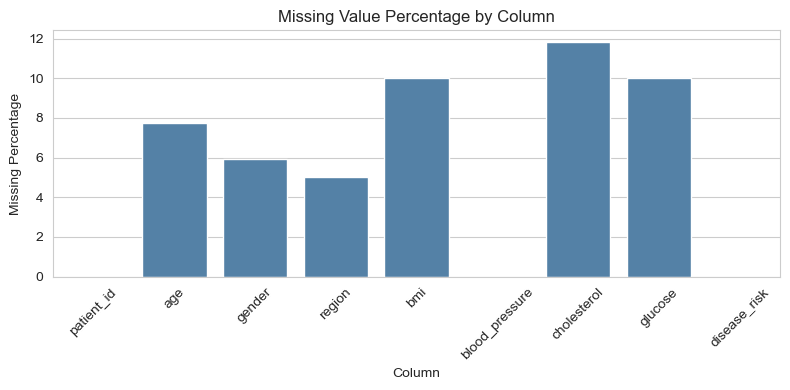

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing Percentage': (df.isnull().mean() * 100).round(2).values
})
display(missing_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=missing_summary, x='Column', y='Missing Percentage', color='steelblue')
plt.title('Missing Value Percentage by Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Simple Imputer (Numeric)

In [192]:
# Simple Imputer (Numerical) using median
simple_df = df.copy()

for col in numeric_missing_cols:
    simple_df[col] = simple_df[col].fillna(simple_df[col].median())

simple_df.head()



,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P001,51.0,Male,East,28.46,158.25,197.67,158.48,1
1,P002,33.0,Female,West,23.27,124.01,205.50,105.37,0
2,P003,57.0,Female,East,30.64,162.38,215.86,129.37,1
3,P004,59.0,Male,East,17.26,148.68,183.96,141.81,0
4,P005,22.0,Male,East,21.89,125.83,183.20,100.66,0


Simple Imputer (Catagory)

In [193]:
# Simple Imputer (Categorical) for region
simple_df['region'] = simple_df['region'].fillna(simple_df['region'].mode()[0])

simple_df[['region']].head()


,region
0,East
1,West
2,East
3,East
4,East


Most Frequent Imputation for gender

In [194]:
# Most Frequent Imputation for gender
simple_df['gender'] = simple_df['gender'].fillna(simple_df['gender'].mode()[0])

simple_df[['gender']].head()

,gender
0,Male
1,Female
2,Female
3,Male
4,Male


 Missing Indicator + Random Sample Imputation



In [195]:
random_df = df.copy()

for col in numeric_missing_cols:
    random_df[f'{col}_missing'] = random_df[col].isna().astype(int)
    random_df[col] = random_sample_impute(random_df[col], seed=42)

random_df['region'] = random_df['region'].fillna(random_df['region'].mode()[0])
random_df['gender'] = random_df['gender'].fillna(random_df['gender'].mode()[0])

random_df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,age_missing,bmi_missing,cholesterol_missing,glucose_missing
0,P001,51.0,Male,East,28.46,158.25,197.67,158.48,1,0,0,0,0
1,P002,33.0,Female,West,23.27,124.01,205.50,105.37,0,0,0,0,0
2,P003,57.0,Female,East,30.64,162.38,215.86,129.37,1,0,0,0,0
3,P004,59.0,Male,East,17.26,148.68,183.96,141.81,0,0,0,0,0
4,P005,22.0,Male,East,21.89,125.83,183.20,100.66,0,0,0,0,0


KNN Imputer



In [196]:
knn_df = df.copy()

knn_df['region'] = knn_df['region'].fillna(knn_df['region'].mode()[0])
knn_df['gender'] = knn_df['gender'].fillna(knn_df['gender'].mode()[0])

knn = KNNImputer(n_neighbors=5)
knn_df[all_numeric_cols] = knn.fit_transform(knn_df[all_numeric_cols])

knn_df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P001,51.0,Male,East,28.46,158.25,197.67,158.48,1
1,P002,33.0,Female,West,23.27,124.01,205.50,105.37,0
2,P003,57.0,Female,East,30.64,162.38,215.86,129.37,1
3,P004,59.0,Male,East,17.26,148.68,183.96,141.81,0
4,P005,22.0,Male,East,21.89,125.83,183.20,100.66,0


MICE Imputer



In [197]:
mice_df = df.copy()

mice_df['region'] = mice_df['region'].fillna(mice_df['region'].mode()[0])
mice_df['gender'] = mice_df['gender'].fillna(mice_df['gender'].mode()[0])

mice = IterativeImputer(random_state=42, max_iter=10)
mice_df[all_numeric_cols] = mice.fit_transform(mice_df[all_numeric_cols])

mice_df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P001,51.0,Male,East,28.46,158.25,197.67,158.48,1
1,P002,33.0,Female,West,23.27,124.01,205.50,105.37,0
2,P003,57.0,Female,East,30.64,162.38,215.86,129.37,1
3,P004,59.0,Male,East,17.26,148.68,183.96,141.81,0
4,P005,22.0,Male,East,21.89,125.83,183.20,100.66,0


 Compare imputation results

In [198]:
comparison_rows = []

for name, data in {
    'Simple Imputer': simple_df,
    'Missing Indicator + Random Sample': random_df,
    'KNN Imputer': knn_df,
    'MICE': mice_df,
}.items():
    comparison_rows.append({
        'Method': name,
        'Missing Values After Imputation': int(data.isnull().sum().sum()),
        'Average BMI': round(data['bmi'].mean(), 2),
        'Average Cholesterol': round(data['cholesterol'].mean(), 2),
        'Average Glucose': round(data['glucose'].mean(), 2),
    })

imputation_comparison = pd.DataFrame(comparison_rows)
imputation_comparison


,Method,Missing Values After Imputation,Average BMI,Average Cholesterol,Average Glucose
0,Simple Imputer,0,26.41,212.80,137.24
1,Missing Indicator + Random Sample,0,26.65,214.19,137.53
2,KNN Imputer,0,26.49,213.13,138.19
3,MICE,0,26.52,213.68,138.01


## Part B: Handling Outliers

In [199]:
from scipy.stats import zscore
from scipy.stats.mstats import winsorize
import seaborn as sns


In [200]:
print("Shape before outlier treatment:", outlier_df.shape)
outlier_df.describe()


Shape before outlier treatment: (220, 9)


,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000
mean,46.201921,26.522408,146.282500,213.675531,138.005545,0.468182
std,11.178093,6.102018,19.453095,38.313129,40.772980,0.500125
min,20.000000,17.000000,99.980000,157.200000,87.730000,0.000000
25%,38.750000,23.200000,135.890000,196.102500,119.637500,0.000000
50%,45.823161,25.932865,144.345000,207.680000,132.900000,0.000000
75%,53.000000,28.252500,153.250000,218.629957,140.325000,1.000000
max,80.000000,56.830000,228.190000,407.350000,339.910000,1.000000


Z-score Method

In [201]:
zscore_df = outlier_df.copy()

z_cols = ['cholesterol', 'glucose']
z_scores = np.abs(zscore(zscore_df[z_cols]))

zscore_filtered_df = zscore_df[(z_scores < 3).all(axis=1)]

print("Shape after Z-score method:", zscore_filtered_df.shape)
zscore_filtered_df.head()


Shape after Z-score method: (200, 9)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P001,51.0,Male,East,28.46,158.25,197.67,158.48,1
1,P002,33.0,Female,West,23.27,124.01,205.50,105.37,0
2,P003,57.0,Female,East,30.64,162.38,215.86,129.37,1
3,P004,59.0,Male,East,17.26,148.68,183.96,141.81,0
4,P005,22.0,Male,East,21.89,125.83,183.20,100.66,0


IQR method for BMI



In [202]:
iqr_df = outlier_df.copy()

Q1 = iqr_df['bmi'].quantile(0.25)
Q3 = iqr_df['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_filtered_df = iqr_df[(iqr_df['bmi'] >= lower_bound) & (iqr_df['bmi'] <= upper_bound)]

print("Shape after IQR method:", iqr_filtered_df.shape)
iqr_filtered_df.head()

Shape after IQR method: (212, 9)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P001,51.0,Male,East,28.46,158.25,197.67,158.48,1
1,P002,33.0,Female,West,23.27,124.01,205.50,105.37,0
2,P003,57.0,Female,East,30.64,162.38,215.86,129.37,1
3,P004,59.0,Male,East,17.26,148.68,183.96,141.81,0
4,P005,22.0,Male,East,21.89,125.83,183.20,100.66,0


 Percentile method



In [203]:
percentile_df = outlier_df.copy()

for col in ['bmi', 'blood_pressure', 'cholesterol', 'glucose']:
    lower = percentile_df[col].quantile(0.01)
    upper = percentile_df[col].quantile(0.99)
    percentile_df[col] = percentile_df[col].clip(lower, upper)

print("Shape after Percentile method:", percentile_df.shape)
percentile_df.head()

Shape after Percentile method: (220, 9)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P001,51.0,Male,East,28.46,158.25,197.67,158.48,1
1,P002,33.0,Female,West,23.27,124.01,205.50,105.37,0
2,P003,57.0,Female,East,30.64,162.38,215.86,129.37,1
3,P004,59.0,Male,East,17.26,148.68,183.96,141.81,0
4,P005,22.0,Male,East,21.89,125.83,183.20,100.66,0


 Winsorization



In [204]:
winsor_df = outlier_df.copy()

for col in ['bmi', 'blood_pressure', 'cholesterol', 'glucose']:
    winsor_df[col] = np.array(winsorize(winsor_df[col], limits=[0.01, 0.01]))

print("Shape after Winsorization:", winsor_df.shape)
winsor_df.head()

Shape after Winsorization: (220, 9)


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P001,51.0,Male,East,28.46,158.25,197.67,158.48,1
1,P002,33.0,Female,West,23.27,124.01,205.50,105.37,0
2,P003,57.0,Female,East,30.64,162.38,215.86,129.37,1
3,P004,59.0,Male,East,17.26,148.68,183.96,141.81,0
4,P005,22.0,Male,East,21.89,125.83,183.20,100.66,0


Compare summary statistics before vs after

In [205]:
print("Before Outlier Treatment")
display(outlier_df[['bmi', 'blood_pressure', 'cholesterol', 'glucose']].describe())

print("After Winsorization")
display(winsor_df[['bmi', 'blood_pressure', 'cholesterol', 'glucose']].describe())

final_df = winsor_df.copy()
final_df.head()

final_df.to_csv("data/patient_health_cleaned.csv", index=False)
print("Final cleaned dataset saved successfully.")

Before Outlier Treatment


,bmi,blood_pressure,cholesterol,glucose
count,220.000000,220.000000,220.000000,220.000000
mean,26.522408,146.282500,213.675531,138.005545
std,6.102018,19.453095,38.313129,40.772980
min,17.000000,99.980000,157.200000,87.730000
25%,23.200000,135.890000,196.102500,119.637500
50%,25.932865,144.345000,207.680000,132.900000
75%,28.252500,153.250000,218.629957,140.325000
max,56.830000,228.190000,407.350000,339.910000


After Winsorization


,bmi,blood_pressure,cholesterol,glucose
count,220.000000,220.000000,220.000000,220.000000
mean,26.495090,146.378136,213.429031,137.985272
std,5.976022,19.155530,36.912447,40.350186
min,17.000000,116.580000,165.470000,94.430000
25%,23.200000,135.890000,196.102500,119.637500
50%,25.932865,144.345000,207.680000,132.900000
75%,28.252500,153.250000,218.629957,140.325000
max,52.390000,224.720000,374.550000,327.980000


Final cleaned dataset saved successfully.


Before outliers and after outliers 

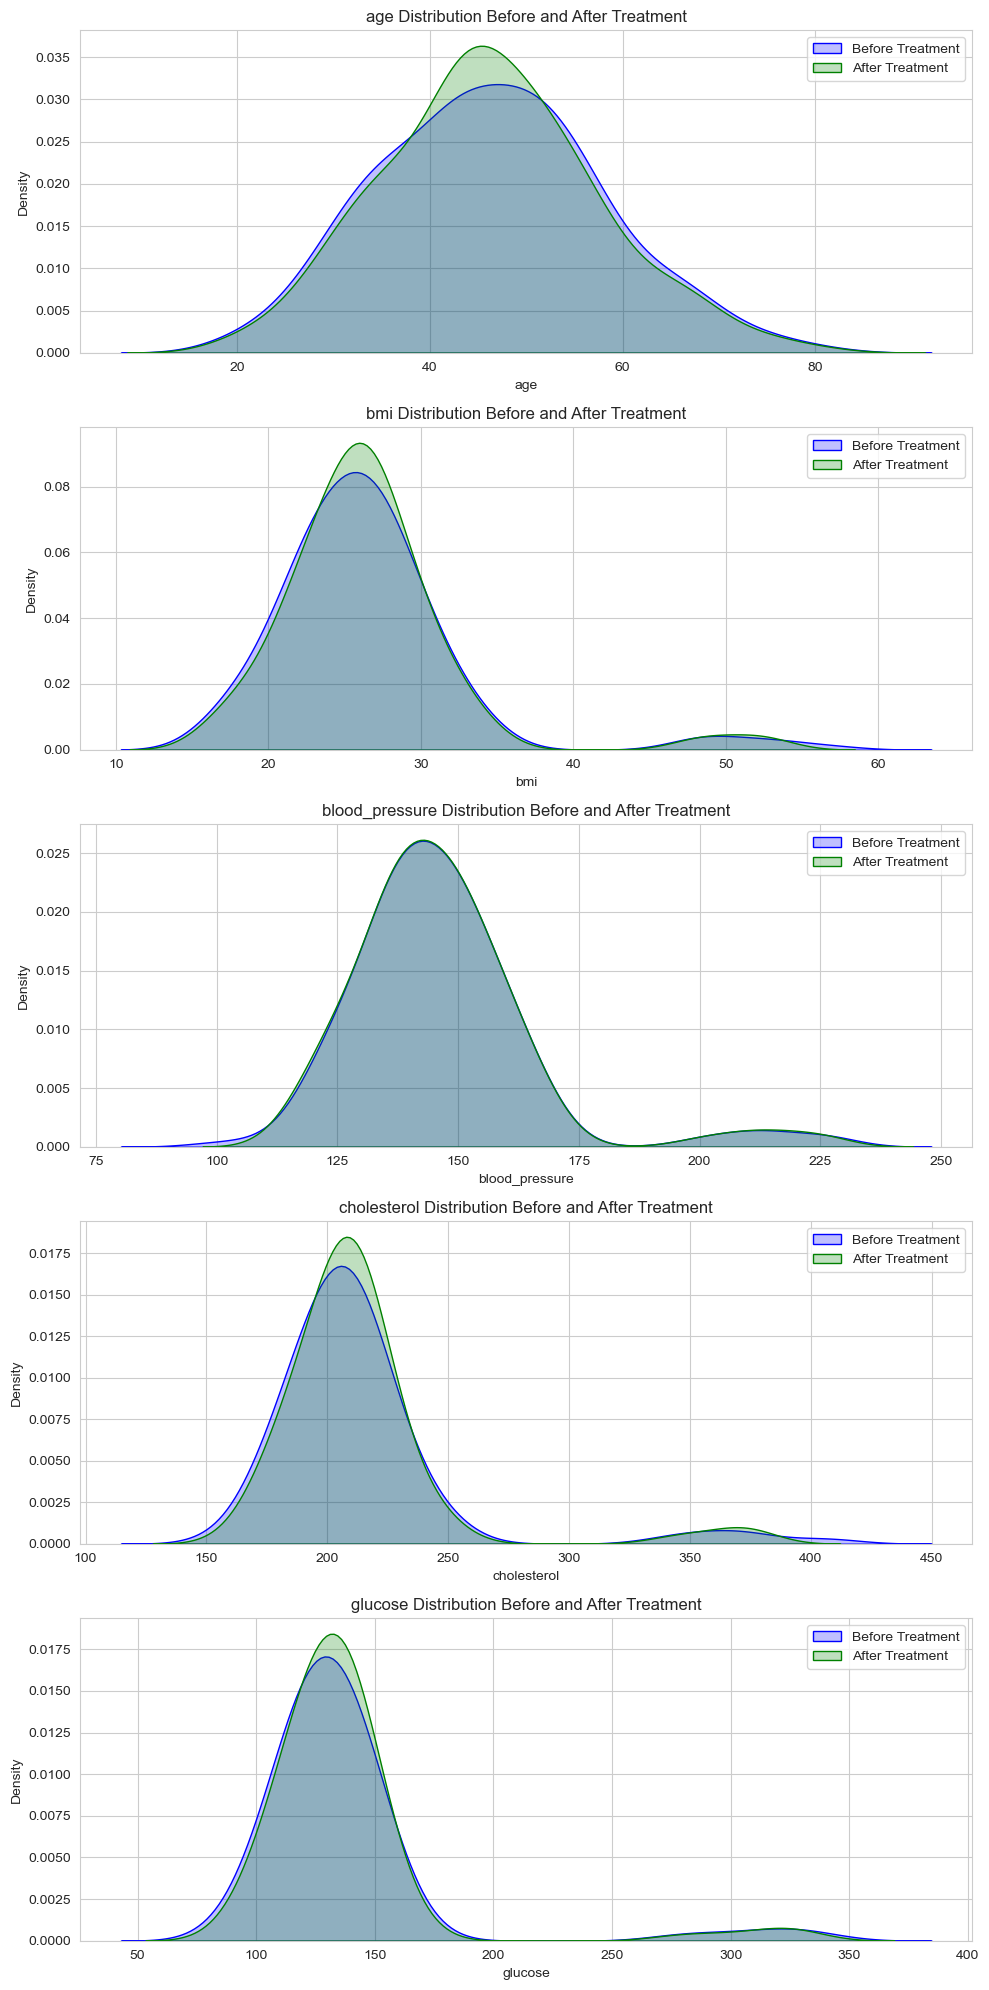

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose']

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 20))

for i, col in enumerate(numeric_cols):
    sns.kdeplot(df[col], label='Before Treatment', fill=True, color='blue', ax=axes[i])
    sns.kdeplot(winsor_df[col], label='After Treatment', fill=True, color='green', ax=axes[i])
    axes[i].set_title(f'{col} Distribution Before and After Treatment')
    axes[i].legend()

plt.tight_layout()
plt.show()



## Part C: Final Clean Dataset

In [207]:
final_df = winsor_df.copy()

final_df.head()

print(final_df.isnull().sum())
print(final_df.duplicated().sum())

print("Final dataset shape:", final_df.shape)

final_df.to_csv("data/patient_health_cleaned.csv", index=False)
print("Final cleaned dataset saved successfully.")

print(final_df.describe())

final_df[['patient_id', 'age', 'gender', 'region', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'disease_risk']].head(10)





patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64
0
Final dataset shape: (220, 9)
Final cleaned dataset saved successfully.
              age         bmi  blood_pressure  cholesterol     glucose  \
count  220.000000  220.000000      220.000000   220.000000  220.000000   
mean    46.201921   26.495090      146.378136   213.429031  137.985272   
std     11.178093    5.976022       19.155530    36.912447   40.350186   
min     20.000000   17.000000      116.580000   165.470000   94.430000   
25%     38.750000   23.200000      135.890000   196.102500  119.637500   
50%     45.823161   25.932865      144.345000   207.680000  132.900000   
75%     53.000000   28.252500      153.250000   218.629957  140.325000   
max     80.000000   52.390000      224.720000   374.550000  327.980000   

       disease_risk  
count    220.000000  
mean       0.468182  


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P001,51.0,Male,East,28.460000,158.25,197.670000,158.480000,1
1,P002,33.0,Female,West,23.270000,124.01,205.500000,105.370000,0
2,P003,57.0,Female,East,30.640000,162.38,215.860000,129.370000,1
3,P004,59.0,Male,East,17.260000,148.68,183.960000,141.810000,0
4,P005,22.0,Male,East,21.890000,125.83,183.200000,100.660000,0
5,P006,30.0,Male,North,25.533332,134.79,205.185911,97.060000,0
6,P007,49.0,Female,North,22.820000,147.20,180.540000,138.004871,0
7,P008,43.0,Female,East,26.660000,147.68,206.620000,320.490000,1
8,P009,47.0,Female,North,25.200000,148.19,215.960000,138.006572,1
9,P010,36.0,Female,North,24.480000,137.40,199.080000,115.210000,1


In [208]:
final_df.to_csv("data/patient_health_cleaned.csv", index=False)

print("Updated final cleaned dataset saved successfully.")


Updated final cleaned dataset saved successfully.


In [209]:
final_df = winsor_df.copy()
final_df['bmi_category'] = pd.cut(final_df['bmi'], bins=[0, 18.5, 25, 30, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
final_df['health_risk_score'] = (0.25 * final_df['bmi'] + 0.2 * final_df['blood_pressure'] + 0.25 * final_df['cholesterol'] / 10 + 0.3 * final_df['glucose'] / 10).round(2)
final_df.to_csv('data/patient_health_cleaned.csv', index=False)

display(final_df.head())
save_table_image(final_df.head(8), 'screenshots/07_final_dataset_preview.png', 'Final Cleaned Dataset Preview')

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,bmi_category,health_risk_score
0,P001,51.0,Male,East,28.46,158.25,197.67,158.48,1,Overweight,48.46
1,P002,33.0,Female,West,23.27,124.01,205.50,105.37,0,Normal,38.92
2,P003,57.0,Female,East,30.64,162.38,215.86,129.37,1,Obese,49.41
3,P004,59.0,Male,East,17.26,148.68,183.96,141.81,0,Underweight,42.90
4,P005,22.0,Male,East,21.89,125.83,183.20,100.66,0,Normal,38.24


In [210]:
print('Final shape:', final_df.shape)
print('Missing values after cleaning:', int(final_df.isnull().sum().sum()))
print('Duplicate rows:', int(final_df.duplicated().sum()))

brief_report = textwrap.dedent(f'''# Brief Report

## Missing Value Strategy
Different imputation methods were tested. MICE was selected for the final dataset because it filled the numerical columns using information from other related variables.

## Outlier Strategy
Winsorization was selected for the final dataset because it reduced extreme values without removing patient records.

## Improvement in Dataset
- Missing values were handled.
- Extreme values were treated.
- Two simple features were added for future machine learning work.
- The dataset is now ready for disease risk prediction.
''').strip()

with open('reports/brief_report.md', 'w', encoding='utf-8') as file:
    file.write(brief_report + '\n')

display(Markdown(brief_report))


Final shape: (220, 11)
Missing values after cleaning: 0
Duplicate rows: 0


# Brief Report

## Missing Value Strategy
Different imputation methods were tested. MICE was selected for the final dataset because it filled the numerical columns using information from other related variables.

## Outlier Strategy
Winsorization was selected for the final dataset because it reduced extreme values without removing patient records.

## Improvement in Dataset
- Missing values were handled.
- Extreme values were treated.
- Two simple features were added for future machine learning work.
- The dataset is now ready for disease risk prediction.